In [1]:
import numpy as np
import sys
import os
import VBMicrolensing
import emcee
import h5py
import math
import matplotlib.pyplot as plt
import concurrent.futures
import corner
from tqdm import tqdm
VBM = VBMicrolensing.VBMicrolensing()
JD0 = 2450000
from matplotlib.lines import Line2D
sys.path.append("/moao38_7/nunota/gapmoe/src/gapmoe/")
from gapmoe import gapmoe
import EarthMotion
import parametrics

import jax
import jax.numpy as jnp
from jax import jacfwd
from jax import jit
from jax import vmap

In [2]:
tref = 10063.874

RA_str,Dec_str = "17:57:38.03","-28:38:28.53"
RA_deg = EarthMotion.hms_string_to_degrees(RA_str)
Dec_deg = EarthMotion.dms_string_to_degrees(Dec_str)
vEarth = EarthMotion.calc_vEarth(tref,RA_deg,Dec_deg)

In [26]:
import matplotlib as mpl
mpl.rc('font', **{'family': 'serif', 'serif': ['Liberation Serif', 'DejaVu Serif']})
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    "font.size": 20,
    "axes.labelsize": 15,
    "axes.titlesize": 18,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "axes.edgecolor": "0.3",
    "axes.linewidth": 1.4,
    "grid.alpha": 0.25,
    "xtick.direction": "out",
    "ytick.direction": "in",
})

plt.rcParams.update({
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "xtick.minor.size": 3,
    "ytick.minor.size": 3,
    "xtick.major.size": 6,
    "ytick.major.size": 6,
})

In [4]:
labels_phys_muEN = [
    r"$\log_{10}(M_{\rm L}/M_\odot)$",
    r"$\log_{10}(D_{\rm L}/{\rm kpc})$",
    r"$\log_{10}(D_{\rm S}/{\rm kpc})$",
    r"$\mu_{\rm rel,N}\ [{\rm mas/yr}]$",
    r"$\mu_{\rm rel,E}\ [{\rm mas/yr}]$"
]

In [5]:
column_names = " wtj          M_L   D_L   D_S          t_E      theta_E         pi_E         pi_EN         pi_EE       mu_rel        mu_Sl        mu_Sb     I_L iS iL fREM".strip().split()

path_prior = "../test_gal_result/genout_prior.dat"
data_gal_prior = np.genfromtxt(path_prior, names=column_names)

data_gal_muN = data_gal_prior["mu_rel"] * np.cos(np.arctan2(data_gal_prior["pi_EE"], data_gal_prior["pi_EN"]))
data_gal_muE = data_gal_prior["mu_rel"] * np.sin(np.arctan2(data_gal_prior["pi_EE"], data_gal_prior["pi_EN"]))
mu_tot_flat = np.sqrt(data_gal_muN**2 + data_gal_muE**2)
mask_flat = mu_tot_flat < 20

flat_prior_log_data = np.vstack([
    np.log10(data_gal_prior["M_L"][mask_flat]),
    np.log10(data_gal_prior["D_L"][mask_flat] * 1e-3),
    np.log10(data_gal_prior["D_S"][mask_flat] * 1e-3),
    data_gal_muN[mask_flat],
    data_gal_muE[mask_flat]
]).T

In [6]:
thS=7.168075e-05

def physical_to_lightcurve_kepler(theta):
    t0 = theta[0]
    tE     = theta[1]
    u0 = theta[2]
    rho    = theta[3]
    q = theta[4]
    s      = theta[5]
    alpha = theta[6]
    piEN   = theta[7]
    piEE   = theta[8]
    gamma1 = theta[9]
    gamma2 = theta[10]
    gamma3 = theta[11]
    r_s = theta[12]
    a_s = theta[13] 
    vEarth_N, vEarthE = vEarth
    
    G = 2.959122082855911e-4 # [AU^3 / (Msun * day^2)]
    KAPPA = 8.1429 # [mas / Msun]

    piE = jnp.sqrt(piEN**2 + piEE**2)

    thE = thS / rho #mas
    ML = thE / KAPPA / piE #Msun
    murel_geo = thE / tE * 365.25 # mas / year
    murel_N_geo = murel_geo * piEN / piE # mas / year
    murel_E_geo = murel_geo * piEE / piE # mas / year


    gamma_sq = gamma1**2 + gamma2**2 + gamma3**2
    gamma_abs = jnp.sqrt(gamma_sq)
    a_norm = a_s * s * jnp.sqrt(1 + r_s**2)
    orbital_scale = jnp.cbrt((s**2) * a_norm * gamma_sq / (ML * G) / (2 * a_s - 1))
    orbital_scale = jnp.cbrt((s**3) * a_s * jnp.sqrt(1 + r_s**2) * gamma_sq / (ML * G) / (2 * a_s - 1))
    Ds = 1 / ((orbital_scale - piE) * thE) #kpc

    pi_rel = thE * piE
    pi_S = 1 / Ds
    pi_L = pi_rel + pi_S
    DL = 1 / pi_L #kpc
    
    murel_N_hel = murel_N_geo + thE * piE * vEarth[0]
    murel_E_hel = murel_E_geo + thE * piE * vEarth[1]

    RE = DL * thE # AU
    orbital_radi = RE * a_norm #AU

    r = RE * s * jnp.array([1,0, r_s]) #AU
    v = RE * s * jnp.array([gamma1,gamma2,gamma3]) #AU / day
    
    h = jnp.cross(r,v)
    A = jnp.cross(v,h) / (G*ML) - r / jnp.sqrt(jnp.dot(r,r))
    e = jnp.sqrt(jnp.dot(A,A))
    
    z = h / jnp.sqrt(jnp.dot(h,h))
    x = A / e
    y = jnp.cross(z,x)
    
    cos_i = z[2]
    sin_i = jnp.sqrt(1 - cos_i**2)
    
    sin_Om0, cos_Om0 = z[0] / sin_i, - z[1] / sin_i
    Om0 = jnp.arctan2(sin_Om0, cos_Om0)
    Om_NE = Om0 + jnp.arctan2(piEE,piEN) + jnp.pi - alpha
    
    sin_om, cos_om = x[2] / sin_i, y[2] / sin_i
    om = jnp.arctan2(sin_om, cos_om)
    
    cos_nu = jnp.dot(r,x)/jnp.sqrt(jnp.dot(r,r))
    sin_nu = jnp.dot(r,y)/jnp.sqrt(jnp.dot(r,r))
    nu = jnp.arctan2(sin_nu,cos_nu)

    return  jnp.array([t0, u0, q, ML, DL, Ds, murel_N_hel, murel_E_hel, orbital_radi, e, cos_i, Om_NE, om, nu])

def physical_to_lightcurve_circular(theta):
    t0 = theta[0]
    tE     = theta[1]
    u0 = theta[2]
    rho    = theta[3]
    q = theta[4]
    s      = theta[5]
    alpha = theta[6]
    piEN   = theta[7]
    piEE   = theta[8]
    gamma1 = theta[9]
    gamma2 = theta[10]
    gamma3 = theta[11]
    vEarth_N, vEarthE = vEarth
    
    G = 2.959122082855911e-4 # [AU^3 / (Msun * day^2)]
    KAPPA = 8.1429 # [mas / Msun]

    piE = jnp.sqrt(piEN**2 + piEE**2)

    thE = thS / rho #mas
    ML = thE / KAPPA / piE #Msun
    murel_geo = thE / tE * 365.25 # mas / year
    murel_N_geo = murel_geo * piEN / piE # mas / year
    murel_E_geo = murel_geo * piEE / piE # mas / year

    gamma_sq = gamma1**2 + gamma2**2 + gamma3**2
    gamma_parallel = jnp.sqrt(gamma1**2 + gamma3**2)
    gamma_ratio = jnp.sqrt(1 + (gamma1/gamma3)**2)
    orbital_scale = jnp.cbrt((s**3) * gamma_sq * gamma_ratio / (ML * G))
    gamma_abs = jnp.sqrt(gamma_sq)
    Ds = 1 / ((orbital_scale - piE) * thE) #kpc

    pi_rel = thE * piE
    pi_S = 1 / Ds
    pi_L = pi_rel + pi_S
    DL = 1 / pi_L #kpc
    
    murel_N_hel = murel_N_geo + thE * piE * vEarth[0]
    murel_E_hel = murel_E_geo + thE * piE * vEarth[1]
    
    RE = DL * thE # AU
    orbital_radi = RE * s * gamma_ratio #AU

    r = RE * s * jnp.array([1,0, - gamma1 / gamma3]) #AU
    v = RE * s * jnp.array([gamma1,gamma2,gamma3]) #AU / day
    
    h = jnp.cross(r,v)
    
    z = h / jnp.sqrt(jnp.dot(h,h))
    
    cos_i = z[2]
    sin_i = jnp.sqrt(1 - cos_i**2)
    sin_Om0, cos_Om0 = z[0] / sin_i, - z[1] / sin_i
    Om0 = jnp.arctan2(sin_Om0, cos_Om0)
    Om_NE = Om0 + jnp.arctan2(piEE,piEN) + np.pi - alpha
    
    x = jnp.array([cos_Om0,sin_Om0,0])
    y = jnp.cross(z,x)
    
    cos_phi0 = jnp.dot(r,x)/jnp.sqrt(jnp.dot(r,r))
    sin_phi0 = jnp.dot(r,y)/jnp.sqrt(jnp.dot(r,r))
    phi0 = jnp.arctan2(sin_phi0,cos_phi0)

    return  jnp.array([t0, u0, q, ML, DL, Ds, murel_N_hel, murel_E_hel, orbital_radi, cos_i, Om_NE, phi0])

In [7]:
prior_variants = [
    { 
        "name": "Prior A",
        "color": "C1",
        "bounds": {
            "t0": (10000,11000),
            "tE":    (0, 1000),
            "u0": (-5,5),
            "rho":   (0, 1),
            "q": (1e-5,1),
            "s":     (0, 5),
            "alpha": (-np.pi,np.pi),
            "piEN":  (-3, 3),
            "piEE":  (-3, 3),
            "gamma1": (-3, 3),
            "gamma2": (-3, 3),
            "gamma3": (-3, 3),
            "r_s": (-10,10),
            "a_s": (0,10)
        }
    }
]

In [8]:
def generate_nonuni_log_data(bounds_dict, N=100000):
    rng = np.random.default_rng(seed=42)
    samples = np.stack([
        rng.uniform(low, high, N)
        for (low, high) in bounds_dict.values()
    ], axis=-1)
    
    physical_params = vmap(physical_to_lightcurve_kepler)(jnp.array(samples))
    
    ML = np.array(physical_params[:, 3])
    DL = np.array(physical_params[:, 4])
    DS = np.array(physical_params[:, 5])
    muN = np.array(physical_params[:, 6])
    muE = np.array(physical_params[:, 7])

    valid_mask = (DL > 0) & (DS > 0)
    ML = ML[valid_mask]
    DL = DL[valid_mask]
    DS = DS[valid_mask]
    muN = muN[valid_mask]
    muE = muE[valid_mask]

    mu_tot = np.sqrt(muN**2 + muE**2)
    mask = mu_tot < 20

    log_data = np.vstack([
        np.log10(ML[mask]),
        np.log10(DL[mask]),
        np.log10(DS[mask]),
        muN[mask],
        muE[mask]
    ]).T

    return log_data

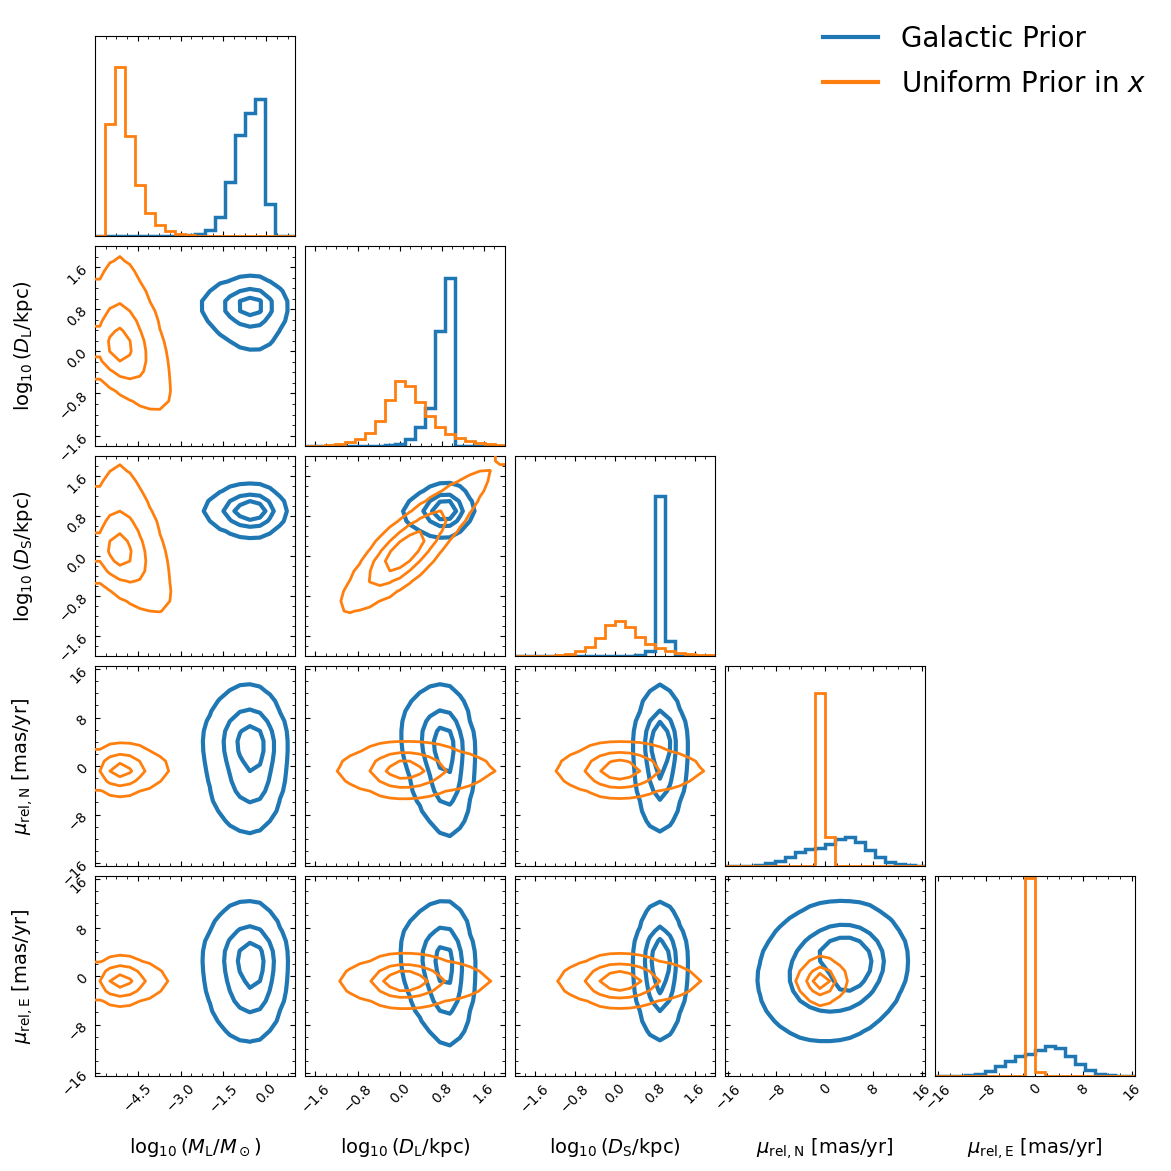

In [9]:
ranges = [
    (-6, 1),       # logML
    (-1.8, 2),     # logDL
    (-2, 2),    # logDS
    (-16.5, 16.5),         # mu_rel_N
    (-16.5, 16.5)        # mu_rel_E
]

fig = corner.corner(
    flat_prior_log_data,
    labels=labels_phys_muEN,
    color="C0",
    hist_kwargs={"density": True, "linewidth": 2.5, "alpha": 1},
    label_kwargs={"fontsize": 14},
    contour_kwargs={"zorder": 5, "linewidths": 3},
    levels=(0.30, 0.68, 0.95),
    fill_contours=False,
    show_titles=False,
    plot_density=False,
    plot_datapoints=False,
    smooth=1.0,
    range=ranges
)

legend_handles = [
    Line2D([0], [0], color="C0", lw=3, label="Galactic Prior")
]

for variant in prior_variants:
    log_data = generate_nonuni_log_data(variant["bounds"])
    corner.corner(
        log_data,
        fig=fig,
        color=variant["color"],
        hist_kwargs={"density": True, "linewidth": 2, "alpha": 1},
        contour_kwargs={"zorder": 6, "linewidths": 2, "alpha": 1},
        levels=(0.30, 0.68, 0.95),
        fill_contours=False,
        show_titles=False,
        plot_density=False,
        plot_datapoints=False,
        smooth=1.0,
        range=ranges
    )
    legend_handles.append(
        Line2D([0], [0], color=variant["color"], lw=3, label=r"Uniform Prior in $x$")
    )

ndim = 5
axes = np.array(fig.axes).reshape((ndim, ndim))
diag_ylims = [1.2, 3, 5.5, 0.6, 0.6]
for i in range(ndim):
    for j in range(ndim):
        ax = axes[i, j]
        ax.minorticks_on()
        ax.tick_params(which="both", direction="in", top=True, right=True)
    axes[i, i].set_ylim(0, diag_ylims[i])

fig.legend(
    handles=legend_handles,
    loc="upper right",
    fontsize=20,
    frameon=False,
    labelspacing=0.6
)

plt.savefig("../test_figures/compare_prior.pdf")

plt.show()

In [10]:
def generate_nonuni_log_data_circular(bounds_dict, N=100000):
    rng = np.random.default_rng(seed=42)
    samples = np.stack([
        rng.uniform(low, high, N)
        for (low, high) in bounds_dict.values()
    ], axis=-1)
    
    physical_params = vmap(physical_to_lightcurve_circular)(jnp.array(samples))
    
    ML = np.array(physical_params[:, 3])
    DL = np.array(physical_params[:, 4])
    DS = np.array(physical_params[:, 5])
    muN = np.array(physical_params[:, 6])
    muE = np.array(physical_params[:, 7])

    valid_mask = (DL > 0) & (DS > 0)
    ML = ML[valid_mask]
    DL = DL[valid_mask]
    DS = DS[valid_mask]
    muN = muN[valid_mask]
    muE = muE[valid_mask]

    mu_tot = np.sqrt(muN**2 + muE**2)
    mask = mu_tot < 20

    log_data = np.vstack([
        np.log10(ML[mask]),
        np.log10(DL[mask]),
        np.log10(DS[mask]),
        muN[mask],
        muE[mask]
    ]).T

    return log_data

In [11]:
prior_variants = [
    { 
        "name": "Prior A",
        "color": "C1",
        "bounds": {
            "t0": (10000,11000),
            "tE":    (0, 1000),
            "u0": (-5,5),
            "rho":   (0, 1),
            "q": (1e-5,1),
            "s":     (0, 5),
            "alpha": (-np.pi,np.pi),
            "piEN":  (-3, 3),
            "piEE":  (-3, 3),
            "gamma1": (-1, 1),
            "gamma2": (-1, 1),
            "gamma3": (-1, 1),
        }
    }
]

log_data = generate_nonuni_log_data_circular(variant["bounds"])

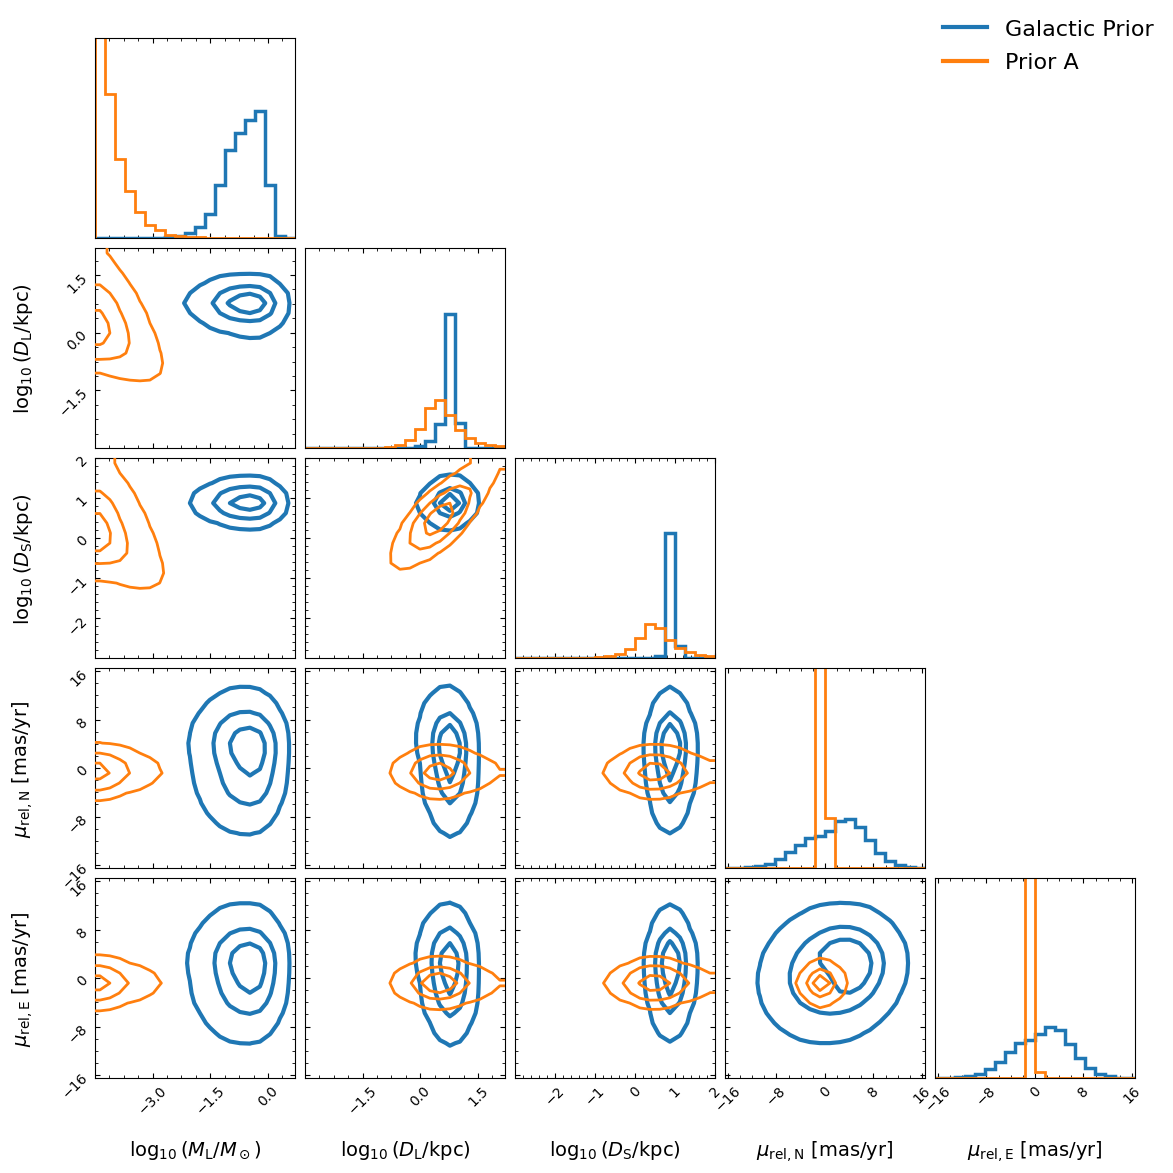

In [12]:
ranges = [
    (-4.5, 0.7),       # logML
    (-3, 2.2),     # logDL
    (-3, 2),    # logDS
    (-16.5, 16.5),         # mu_rel_N
    (-16.5, 16.5)        # mu_rel_E
]

fig = corner.corner(
    flat_prior_log_data,
    labels=labels_phys_muEN,
    color="C0",
    hist_kwargs={"density": True, "linewidth": 2.5, "alpha": 1},
    label_kwargs={"fontsize": 14},
    contour_kwargs={"zorder": 5, "linewidths": 3},
    levels=(0.30, 0.68, 0.95),
    fill_contours=False,
    show_titles=False,
    plot_density=False,
    plot_datapoints=False,
    smooth=1.0,
    range=ranges
)

legend_handles = [
    Line2D([0], [0], color="C0", lw=3, label="Galactic Prior")
]

for variant in prior_variants:
    log_data = generate_nonuni_log_data_circular(variant["bounds"])
    corner.corner(
        log_data,
        fig=fig,
        color=variant["color"],
        hist_kwargs={"density": True, "linewidth": 2, "alpha": 1},
        contour_kwargs={"zorder": 6, "linewidths": 2, "alpha": 1},
        levels=(0.30, 0.68, 0.95),
        fill_contours=False,
        show_titles=False,
        plot_density=False,
        plot_datapoints=False,
        smooth=1.0,
        range=ranges
    )
    legend_handles.append(
        Line2D([0], [0], color=variant["color"], lw=3, label=variant["name"])
    )

ndim = 5
axes = np.array(fig.axes).reshape((ndim, ndim))
diag_ylims = [1.3, 4, 5.7, 0.35, 0.35]
for i in range(ndim):
    for j in range(ndim):
        ax = axes[i, j]
        ax.minorticks_on()
        ax.tick_params(which="both", direction="in", top=True, right=True)
    axes[i, i].set_ylim(0, diag_ylims[i])

fig.legend(
    handles=legend_handles,
    loc="upper right",
    fontsize=16,
    frameon=False,
    labelspacing=0.6,
)

plt.show()

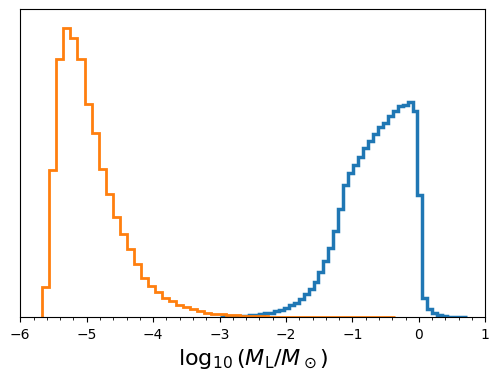

In [13]:
fig, ax = plt.subplots(figsize=(6, 4))

# Galactic prior
ax.hist(
    flat_prior_log_data[:, 0],
    bins=50,
    density=True,
    histtype="step",
    linewidth=2.5,
    color="C0",
    label="Galactic Prior",
)

# variants
for variant in prior_variants:
    log_data = generate_nonuni_log_data(variant["bounds"])
    ax.hist(
        log_data[:, 0],
        bins=50,
        density=True,
        histtype="step",
        linewidth=2,
        color=variant["color"],
        label=r"Uniform Prior in $x$",
    )

ax.set_xlim(-6, 1)
ax.set_ylim(0, 1.2)

ax.set_xlabel(labels_phys_muEN[0], fontsize=16)

ax.minorticks_on()
ax.set_yticks([])
plt.show()

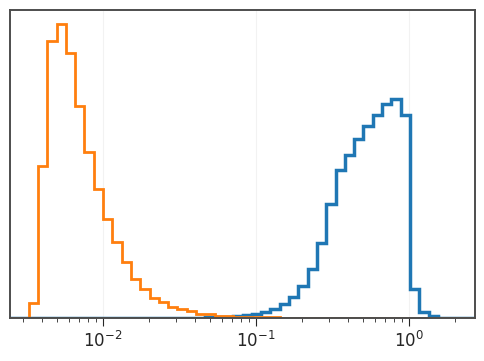

In [29]:
def hist_density_logx(x, bins):
    """
    Return density w.r.t. ln(x): p(ln x)
    so that sum_i p_i * Δlnx_i = 1
    """
    counts, edges = np.histogram(x, bins=bins)
    prob = counts / counts.sum()                       # P_i
    dlnx = np.log(edges[1:]) - np.log(edges[:-1])     # Δlnx_i
    dens = prob / dlnx                                 # p(ln x) in each bin
    return dens, edges

fig, ax = plt.subplots(figsize=(6, 4))

xmin, xmax = np.exp(-6), np.exp(1)
edges = np.logspace(np.log10(xmin), np.log10(xmax), 51)  # 50 bins

x_gal = np.exp(flat_prior_log_data[:, 0])
dens_gal, edges = hist_density_logx(x_gal, edges)
ax.stairs(dens_gal, edges, linewidth=2.5, color="C0", label="Galactic Prior")

for i, variant in enumerate(prior_variants):
    log_data = generate_nonuni_log_data(variant["bounds"])
    x = np.exp(log_data[:, 0])
    dens, _ = hist_density_logx(x, edges)
    ax.stairs(
        dens, edges,
        linewidth=2,
        color=variant["color"],
        label=(r"Uniform Prior in $x$" if i == 0 else None),
    )

ax.set_xscale("log")

ax.set_xlim(xmin, xmax)
ax.set_yticks([])
ax.minorticks_on()

plt.show()